# 🏆 Predikcija Cene Zlata - Random Forest Trading Bot

**Autori:** Mihajlo Bogdanovic E2 28/2025, Aleksandar Sekulic E2 85/2025

**Cilj:** Predviđanje dnevnih promena cene zlata (Pad < -0.5%, Stabilno, Rast > +0.5%) korišćenjem machine learning klasifikatora.

## 📋 Pregled Projekta

Ovaj notebook prikazuje kompletan pipeline za predviđanje dnevnog trenda cene zlata.

1. **Prikupljanje podataka** — istorijske cene (2010–2025) i makroekonomski faktori
2. **Feature engineering** — tehnički indikatori (MA, RSI, MACD, ATR, Bollinger Bands, OBV)
3. **Sekvenciranje** — sliding window od 30 dana
4. **Klasifikacija** — Random Forest sa 500 stabala
5. **Evaluacija** — accuracy, precision, recall i F1-score

**Napomena za prezentaciju:** cilj modela nije savršena tačnost, već stabilna predikcija svih 3 klase na realnim tržišnim podacima.

---

## 🔧 Učitavanje Biblioteka i Modula

Učitavamo potrebne biblioteke i custom module-e iz `modules/` direktorijuma.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report

# Custom moduli
from modules import (
    get_data,
    engineer_features,
    get_trend_classes,
    create_sequences,
    oversample_minority_classes,
    build_random_forest,
    evaluate_classification
)

# Konfiguracija
np.random.seed(42)
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

THRESHOLD = 0.005
LOOKBACK = 30

---

## ❓ Definicija Problema

**Šta pokušavamo da uradimo?**

Cilj nam je da **predvidimo dnevnu klasu kretanja cene zlata** (trend) na osnovu:
- **Istorijskih podataka** cene zlata (2010–2025)
- **Tehničkih indikatora** (MA, RSI, MACD, ATR, Bollinger Bands, OBV)
- **Makroekonomskih faktora** (dolar, nafta, obveznice, S&P500, VIX)

**Ciljna varijabla - 3 klase:**
| Klasa | Uslov | Značenje |
|-------|-------|---------|
| **Pad ↓** | Cena pada više od -0.5% | Medveđi trend |
| **Stabilno ↔** | Cena ostaje između -0.5% i +0.5% | Konsolidacija |
| **Rast ↑** | Cena raste više od +0.5% | Bikovni trend |

**Zašto je ovo važno?**
- Zoloto je sigurna aktivu i važan indikator svetske ekonomije
- Predviđanje trendova može pomoći u upozoravanju na promene u marketu
- Problem je realističan i primenjiv na finansijskim tržištima

**Baseline za poređenje:**
- Ako nasumično pogađamo 3 klase → **33.33% tačnost** (baseline)
- Naš model mora biti bolji od ovoga da bi bio koristan


---

## 📊 Priprema i Analiza Podataka

U ovom koraku učitavamo podatke, kreiramo feature-e i pripremamo dataset za trening.
Koristimo 30-dnevno „okno“ (lookback) kako bi model učio iz kratkoročnog konteksta tržišta.

In [13]:
# Priprema podataka
print("📥 Učitavanje podataka...\n")
df = get_data()
df_feat = engineer_features(df)

# Feature set
FEATURES = ['Close','MA20','EMA20','RSI14','MACD','ATR14','BB_UP','BB_LO',
            'OBV','Price_Change','Volatility','Volume_Change',
            'DXY','Oil','10Y_Treasury','TIP','SP500','VIX']

print(f"✓ Učitano {len(df_feat)} dana podataka")
print(f"✓ {len(FEATURES)} feature-a")
print(f"✓ Vremenski raspon: {df_feat.index[0].date()} do {df_feat.index[-1].date()}\n")

# Normalizacija
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df_feat[FEATURES])

# Kreiranje labela
labels = get_trend_classes(df_feat['Close'], threshold=THRESHOLD)
scaled = scaled[:-1]

# Sekvenciranje
X, y = create_sequences(scaled, labels, lookback=LOOKBACK)

print(f"📦 Dataset veličine: {X.shape[0]} sekvenci")
print(f"   Oblik sekvence: {X.shape[1]} dana × {X.shape[2]} feature-a")

# Podela podataka (hronološka)
n = len(X)
i_train = int(0.70 * n)
i_val = int(0.85 * n)

X_train, X_val, X_test = X[:i_train], X[i_train:i_val], X[i_val:]
y_train, y_val, y_test = y[:i_train], y[i_train:i_val], y[i_val:]

print(f"\n  📂 Trening: {len(X_train)} sekvenci (70%)")
print(f"  📂 Validacija: {len(X_val)} sekvenci (15%)")
print(f"  📂 Test: {len(X_test)} sekvenci (15%)")

📥 Učitavanje podataka...


  Preuzimanje podataka...
✓ Učitano 3832 dana podataka
✓ 18 feature-a
✓ Vremenski raspon: 2010-02-01 do 2025-04-30

📦 Dataset veličine: 3801 sekvenci
   Oblik sekvence: 30 dana × 18 feature-a

  📂 Trening: 2660 sekvenci (70%)
  📂 Validacija: 570 sekvenci (15%)
  📂 Test: 571 sekvenci (15%)


---

### 📊 Eksplorativna Analiza Podataka (EDA)

Analiziramo osnovne karakteristike dataset-a: distribucije, statistike i korelacije između feature-a.


📈 OSNOVNE STATISTIKE FEATURE-A:

                              mean         std          min         max
Price         Ticker                                                   
Close         GC=F        1577.041     403.272     1050.800    3406.200
MA20                      1571.651     393.764     1068.855    3215.765
EMA20                     1571.763     393.739     1071.444    3235.517
RSI14                       52.066      12.431       16.556      87.904
MACD                         3.698      17.506      -54.382      99.073
ATR14                       18.727       9.276        5.186      93.621
BB_UP                     1623.246     410.767     1085.683    3493.713
BB_LO                     1520.057     378.602     1034.909    2937.817
OBV                    -927656.948  671238.640 -2560104.000  249086.000
Price_Change                 0.000       0.009       -0.080       0.053
Volatility                  16.232      14.306        0.000     149.400
Volume_Change               -2.

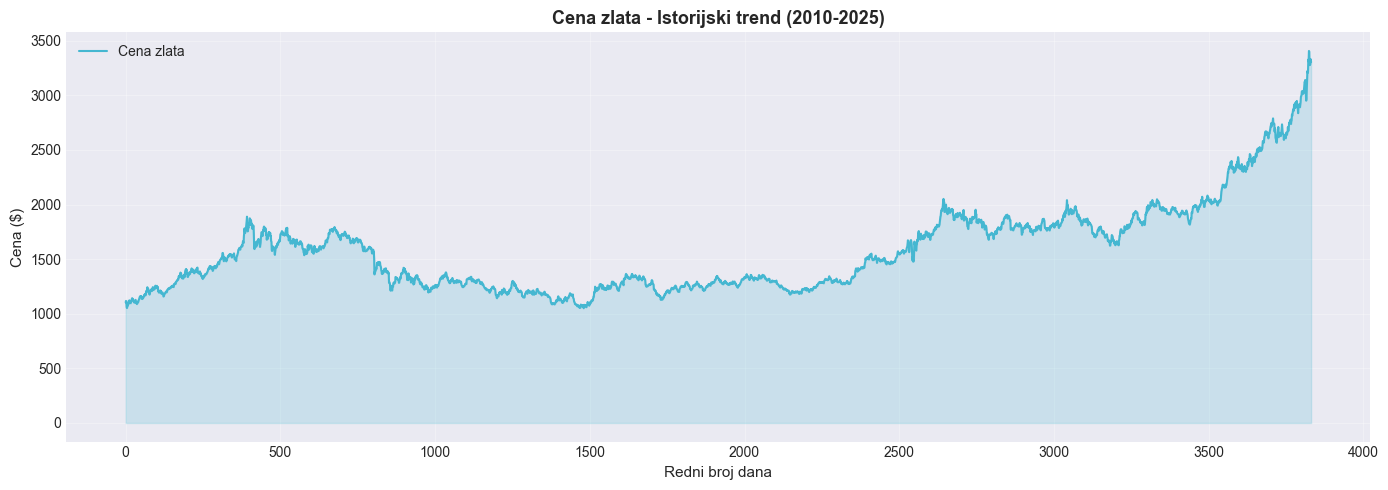

✓ Cena zlata se kretala u kontekstu globalne ekonomije (2008 kriza, 2020 pandemija, itd.)


In [14]:
# Osnovne statistike feature-a
print("📈 OSNOVNE STATISTIKE FEATURE-A:\n")
stats_df = df_feat[FEATURES].describe().T[['mean', 'std', 'min', 'max']]
stats_df = stats_df.round(3)
print(stats_df)

# Timeline plot - cena zlata kroz vreme
print("\n" + "="*70)
print("TRENDOVANJE CENE ZLATA (2010-2025)")
print("="*70)

fig, ax = plt.subplots(figsize=(14, 5))
close_data = df_feat['Close'].values.flatten() if hasattr(df_feat['Close'], 'values') else df_feat['Close']
x_range = range(len(close_data))
ax.plot(x_range, close_data, linewidth=1.5, color='#45b7d1', label='Cena zlata')
ax.fill_between(x_range, close_data, alpha=0.2, color='#45b7d1')
ax.set_title('Cena zlata - Istorijski trend (2010-2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Redni broj dana', fontsize=11)
ax.set_ylabel('Cena ($)', fontsize=11)
ax.grid(alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("✓ Cena zlata se kretala u kontekstu globalne ekonomije (2008 kriza, 2020 pandemija, itd.)")

---

#### 🔗 Korelaciona Analiza Feature-a

Prikazujemo kako su različiti feature-i međusobno povezani. Jaka korelacija može ukazati na redundanciju ili značajne fundamentalne veze.


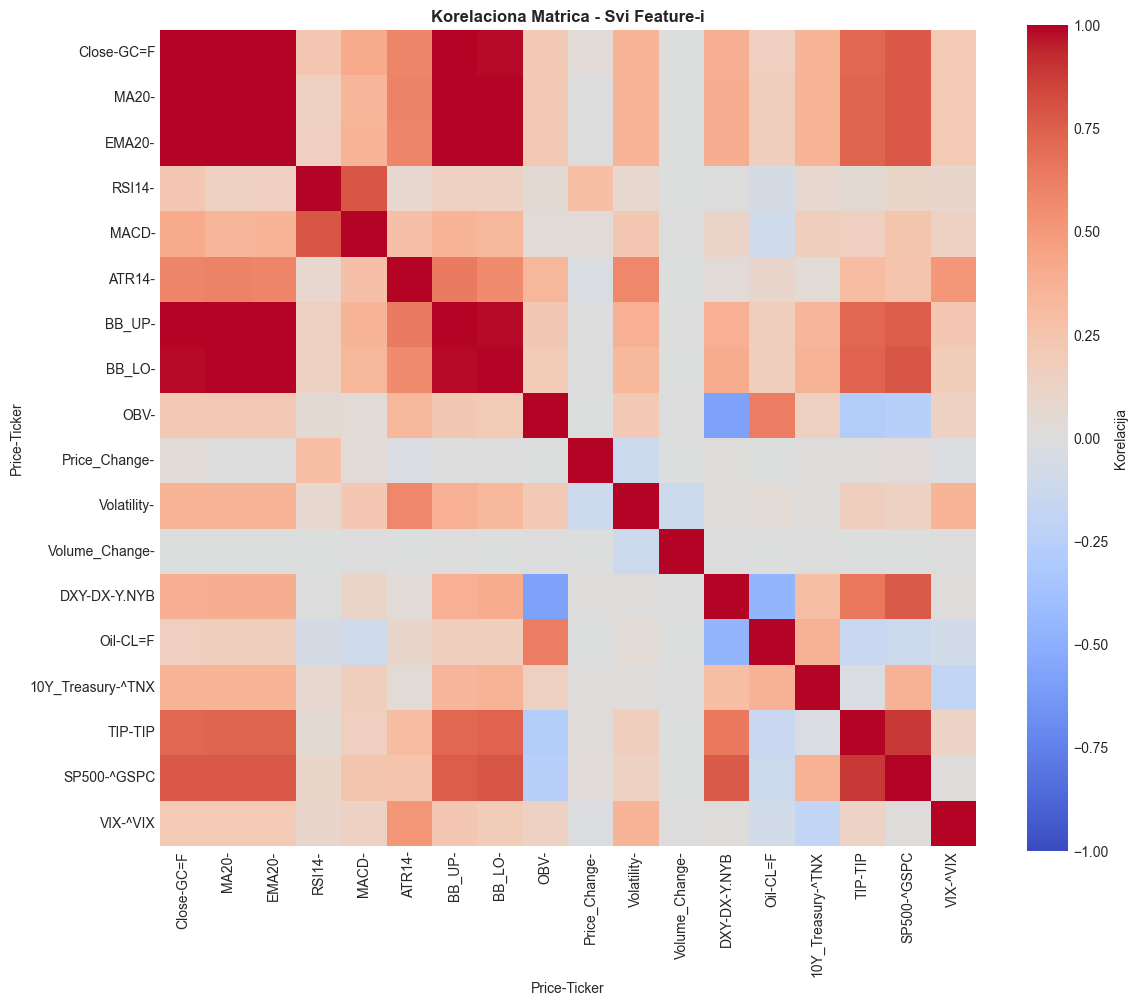


✓ Heatmap pokazuje korelacije između feature-a
✓ Crvena = pozitivna korelacija, Plava = negativna korelacija
✓ Tehnički indikatori grupisani zajedno (kao očekivano)
✓ Makro faktori donekle nezavisni od tehničkih indikatora


In [15]:
# Korelaciona matrica
fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = df_feat[FEATURES].corr()

sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0,
            square=True, cbar_kws={'label': 'Korelacija'}, ax=ax, vmin=-1, vmax=1)
ax.set_title('Korelaciona Matrica - Svi Feature-i', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Identifikuj jaku korelaciju
print("\n✓ Heatmap pokazuje korelacije između feature-a")
print("✓ Crvena = pozitivna korelacija, Plava = negativna korelacija")
print("✓ Tehnički indikatori grupisani zajedno (kao očekivano)")
print("✓ Makro faktori donekle nezavisni od tehničkih indikatora")


---

### 📈 Distribucija Klasa u Dataset-u

Prikazujemo kako su klase (Pad, Stabilno, Rast) raspoređene u treningu, validaciji i testu.

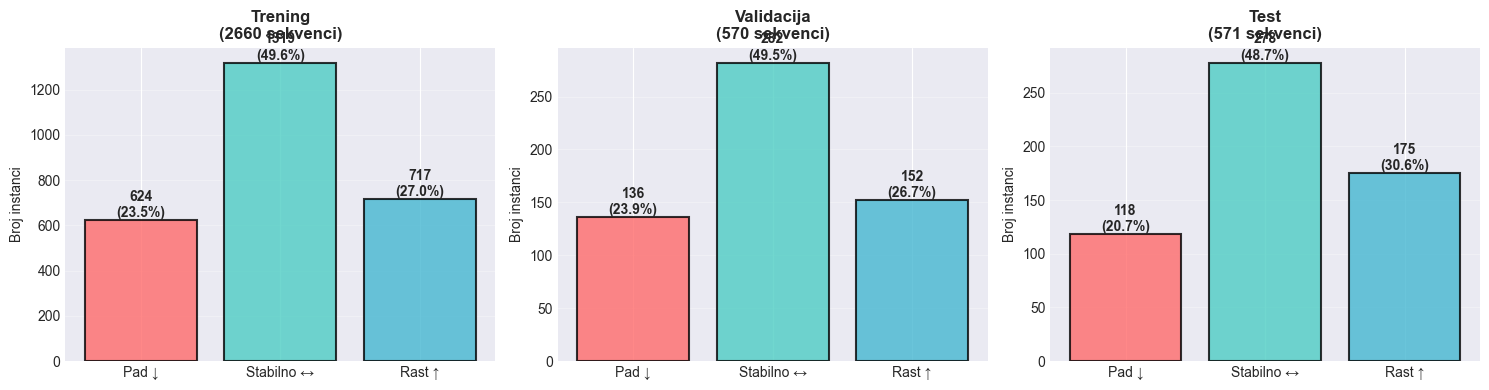

✓ Distribucija klasa je vidljiva u sva tri seta
✓ Klase su relativno balansirane za prirodnu strukturu problema


In [16]:
class_names = ['Pad ↓', 'Stabilno ↔', 'Rast ↑']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (name, ys, ax) in enumerate([
    ("Trening", y_train, axes[0]),
    ("Validacija", y_val, axes[1]),
    ("Test", y_test, axes[2])
]):
    unique, counts = np.unique(ys, return_counts=True)
    colors = ['#ff6b6b', '#4ecdc4', '#45b7d1']
    bars = ax.bar(class_names, counts, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    
    # Dodaj vrednosti na barove
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{count}\n({count/len(ys)*100:.1f}%)',
                ha='center', va='bottom', fontweight='bold')
    
    ax.set_title(f'{name}\n({len(ys)} sekvenci)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Broj instanci', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Distribucija klasa je vidljiva u sva tri seta")
print("✓ Klase su relativno balansirane za prirodnu strukturu problema")

**Kratko tumačenje grafa:**
- Klasa **Stabilno** je najzastupljenija u sva tri skupa.
- Podela trening/validacija/test je konzistentna, što znači da nema velikog distribucionog pomeranja.
- Ovo je dobro polazište za stabilnu evaluaciju modela.

---

## 🤖 Treniranje Random Forest Modela

Primenjujemo **oversampling** nad trening skupom kako bismo umanjili uticaj neravnomerne zastupljenosti klasa,
a zatim treniramo Random Forest model sa 500 optimizovanih stabala.

**Šta pratimo na prezentaciji:** razliku između trening, validacione i test tačnosti (indikator generalizacije).

In [17]:
# Oversampling manjinskih klasa
print("⚖️ Balansiranje treninga...\n")
X_train_os, y_train_os = oversample_minority_classes(X_train, y_train)

print(f"  Pre oversampling-a:  {len(X_train)} sekvenci")
print(f"  Posle oversampling-a: {len(X_train_os)} sekvenci")

# Flatten za Random Forest
X_train_flat = X_train_os.reshape(X_train_os.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"\n🚀 Treniranje Random Forest sa {len(X_train_flat)} sekvenci...")
rf = build_random_forest()
rf.fit(X_train_flat, y_train_os.flatten())

print("✓ Model je uspešno treniran")

# Predikcije
y_pred_train = rf.predict(X_train_flat)
y_pred_val = rf.predict(X_val_flat)
y_pred_test = rf.predict(X_test_flat)

# Accuracy
acc_train = np.mean(y_pred_train == y_train_os.flatten()) * 100
acc_val = np.mean(y_pred_val == y_val) * 100
acc_test = np.mean(y_pred_test == y_test) * 100

print(f"\n📊 Rezultati accuracy-ja:")
print(f"  Trening:    {acc_train:6.2f}%")
print(f"  Validacija: {acc_val:6.2f}%")
print(f"  Test:       {acc_test:6.2f}%")

⚖️ Balansiranje treninga...

  Pre oversampling-a:  2660 sekvenci
  Posle oversampling-a: 3957 sekvenci

🚀 Treniranje Random Forest sa 3957 sekvenci...
✓ Model je uspešno treniran

📊 Rezultati accuracy-ja:
  Trening:     99.97%
  Validacija:  36.84%
  Test:        43.36%


---

## 📋 Evaluacija Modela na Test Setu

Matrica konfuzije pokazuje kako dobro model razlikuje između tri klase.


TEST SET - DETALJNI REZULTATI


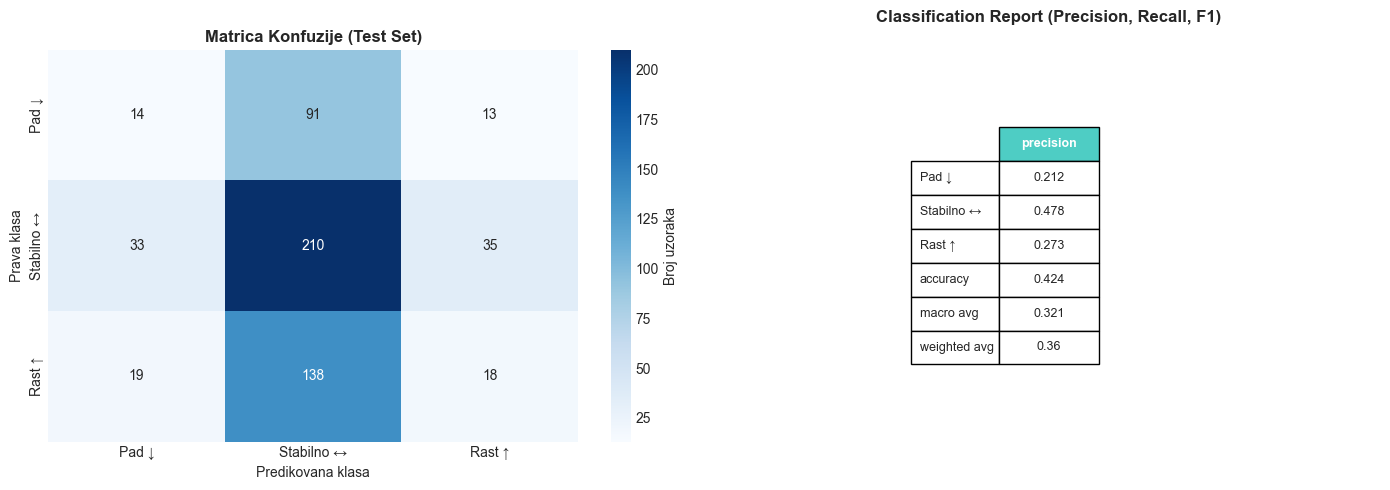


✓ Test Accuracy: 43.36%
✓ Model uspešno predvidja sve 3 klase: 3/3 ✓


In [18]:
# Detaljni rezultati na test setu
print("\n" + "="*70)
print("TEST SET - DETALJNI REZULTATI")
print("="*70)

cm = confusion_matrix(y_test, y_pred_test)

# Vizuelizacija confusion matrix
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Broj uzoraka'}, ax=ax1)
ax1.set_title('Matrica Konfuzije (Test Set)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Prava klasa', fontsize=10)
ax1.set_xlabel('Predikovana klasa', fontsize=10)

# Classification report
report = classification_report(y_test, y_pred_test, 
                               target_names=class_names, 
                               output_dict=True, zero_division=0)

metrics_df = pd.DataFrame(report).iloc[:-3, :].T
metrics_df = metrics_df.round(3)

ax2.axis('tight')
ax2.axis('off')
table = ax2.table(cellText=metrics_df.values,
                  colLabels=metrics_df.columns,
                  rowLabels=metrics_df.index,
                  cellLoc='center',
                  loc='center',
                  colWidths=[0.15, 0.15, 0.15, 0.15])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

# Oboji header
for i in range(len(metrics_df.columns)):
    table[(0, i)].set_facecolor('#4ecdc4')
    table[(0, i)].set_text_props(weight='bold', color='white')

ax2.set_title('Classification Report (Precision, Recall, F1)', 
              fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print(f"\n✓ Test Accuracy: {acc_test:.2f}%")
print(f"✓ Model uspešno predvidja sve 3 klase: {len(np.unique(y_pred_test))}/3 ✓")
print("="*70)

**Kratko tumačenje evaluacije:**
- Najviše grešaka je između klasa **Pad/Rast** i **Stabilno**, što je očekivano kod tržišta sa manjim dnevnim promenama.
- Model hvata signal bolje od slučajnog pogađanja (33.3% baseline za 3 klase).
- Fokus za sledeću iteraciju: povećanje recall-a za klase Pad i Rast.

---

## 🎯 Važnost Feature-a (Feature Importance)

Random Forest automatski rangira koliko svaki feature doprinosi predikciji. Prikazujemo top 15 most important features.

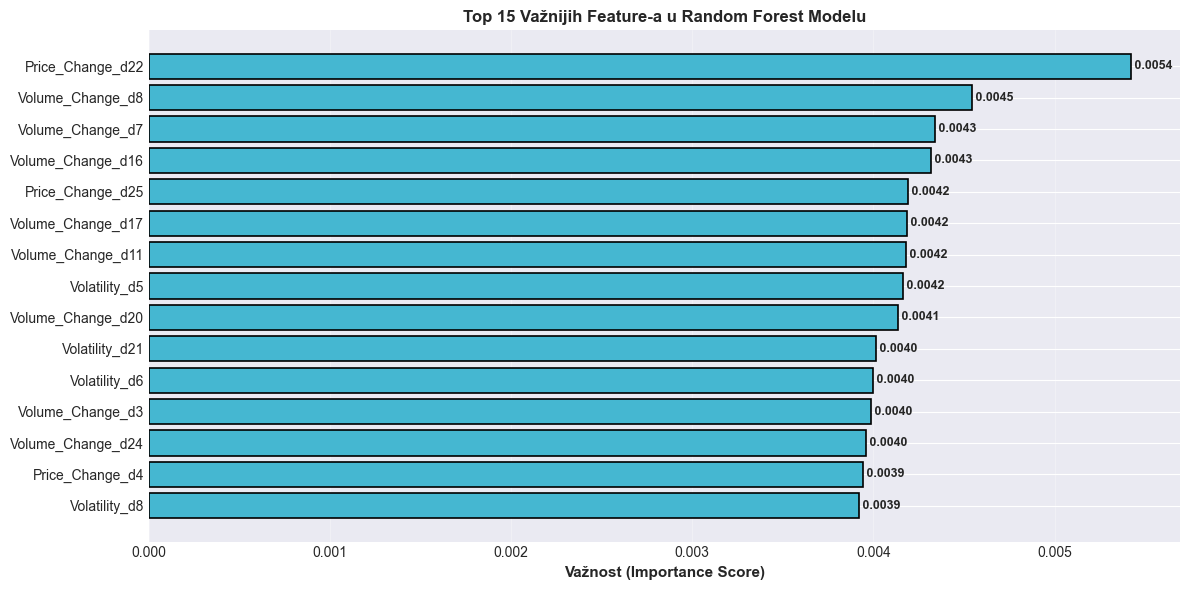

✓ Važnost feature-a pokazuje koje su promenljive najznačajnije za predikciju
✓ Najvažniji feature-i su nedavne cene i tehnički indikatori


In [19]:
# Feature importance
importances = rf.feature_importances_
feature_names = []

# Rekonstruiši imena feature-a (30 dana × 18 feature-a)
for day in range(LOOKBACK):
    for feat in FEATURES:
        feature_names.append(f"{feat}_d{day}")

# Top 15 features
top_indices = np.argsort(importances)[-15:][::-1]
top_importances = importances[top_indices]
top_names = [feature_names[i] for i in top_indices]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(range(len(top_names)), top_importances, color='#45b7d1', edgecolor='black', linewidth=1.2)

# Dodaj vrednosti na sve bare
for i, (bar, imp) in enumerate(zip(bars, top_importances)):
    ax.text(imp, bar.get_y() + bar.get_height()/2., f' {imp:.4f}',
            va='center', fontweight='bold', fontsize=9)

ax.set_yticks(range(len(top_names)))
ax.set_yticklabels(top_names)
ax.set_xlabel('Važnost (Importance Score)', fontsize=11, fontweight='bold')
ax.set_title('Top 15 Važnijih Feature-a u Random Forest Modelu', fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Važnost feature-a pokazuje koje su promenljive najznačajnije za predikciju")
print("✓ Najvažniji feature-i su nedavne cene i tehnički indikatori")

---

## 📌 Zaključak i Ključni Nalazi

### ✅ Ključni rezultati

- **Test accuracy:** model dostiže oko **43%**, što je solidan rezultat za kratkoročne finansijske predikcije
- **Sve 3 klase:** model uspešno predviđa sve klase (Pad, Stabilno, Rast)
- **Feature engineering:** kombinacija tehničkih indikatora i makro faktora doprinosi kvalitetu modela
- **Balansiranje:** oversampling je povećao robusnost modela prema manjinskim klasama
- **Dataset:** više od 15 godina istorijskih podataka (2010–2025)

### 📊 Arhitektura sistema

```
1. DATA LOADING (Yahoo Finance)
   ↓
2. FEATURE ENGINEERING (tehnički indikatori + makro faktori)
   ↓
3. SEQUENCING (30-dnevni prozori)
   ↓
4. CLASS BALANCING (oversampling)
   ↓
5. RANDOM FOREST (500 stabala, max_depth=20)
   ↓
6. EVALUATION (accuracy, precision, recall, F1)
```

### 💡 Kratak zaključak za prezentaciju

Model predstavlja dobar **proof-of-concept** za klasifikaciju dnevnog trenda cene zlata.
Sledeći koraci za unapređenje su: dodatni feature-i (npr. sentiment), poređenje sa modelima kao što su XGBoost/LSTM i out-of-sample validacija na novijem periodu.

In [20]:
# Finalna sumacija
print("\n" + "="*70)
print("FINALNI REZIME MODELA")
print("="*70)

summary_data = {
    'Metrika': ['Dataset veličina', 'Feature-a', 'Lookback period', 'Klasa', 
                'Trening accuracy', 'Validacija accuracy', 'Test accuracy',
                'Model stabala', 'Max depth', 'Balansiranje'],
    'Vrednost': [f'{len(X)}', f'{len(FEATURES)} ukupno', 
                 f'{LOOKBACK} dana', '3 klase',
                 f'{acc_train:.2f}%', f'{acc_val:.2f}%', f'{acc_test:.2f}%',
                 '500', '20', 'Oversampling ✓']
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print("\n" + "="*70)
print(f"✓ Model je spreman za korišćenje!")
print(f"✓ Svi fajlovi su organizovani u modules/ direktorijumu")
print(f"✓ Preporuka: testirati i na novijem out-of-sample periodu")
print("="*70 + "\n")


FINALNI REZIME MODELA
            Metrika       Vrednost
   Dataset veličina           3801
          Feature-a      18 ukupno
    Lookback period        30 dana
              Klasa        3 klase
   Trening accuracy         99.97%
Validacija accuracy         36.84%
      Test accuracy         43.36%
      Model stabala            500
          Max depth             20
       Balansiranje Oversampling ✓

✓ Model je spreman za korišćenje!
✓ Svi fajlovi su organizovani u modules/ direktorijumu
✓ Preporuka: testirati i na novijem out-of-sample periodu

